行程数据分析 回归建模 yellow_taxi_travel_regression

数据集大小: 1,813,737 行, 17 列
列名: ['tip_amount', 'trip_distance', 'passenger_count', 'fare_amount', 'trip_duration_minutes', 'hour_of_day', 'is_weekend', 'is_peak_hour', 'is_night', 'fare_per_mile', 'revenue_per_minute', 'tip_rate', 'is_hot_pu', 'PULocationID', 'payment_type', 'distance_code', 'payment_code']

=== 数据基本信息 ===
<class 'pandas.DataFrame'>
RangeIndex: 1813737 entries, 0 to 1813736
Data columns (total 17 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   tip_amount             float64
 1   trip_distance          float64
 2   passenger_count        float64
 3   fare_amount            float64
 4   trip_duration_minutes  float64
 5   hour_of_day            int8   
 6   is_weekend             bool   
 7   is_peak_hour           bool   
 8   is_night               bool   
 9   fare_per_mile          float64
 10  revenue_per_minute     float64
 11  tip_rate               float64
 12  is_hot_pu              bool   
 13  PULocationID           int64  


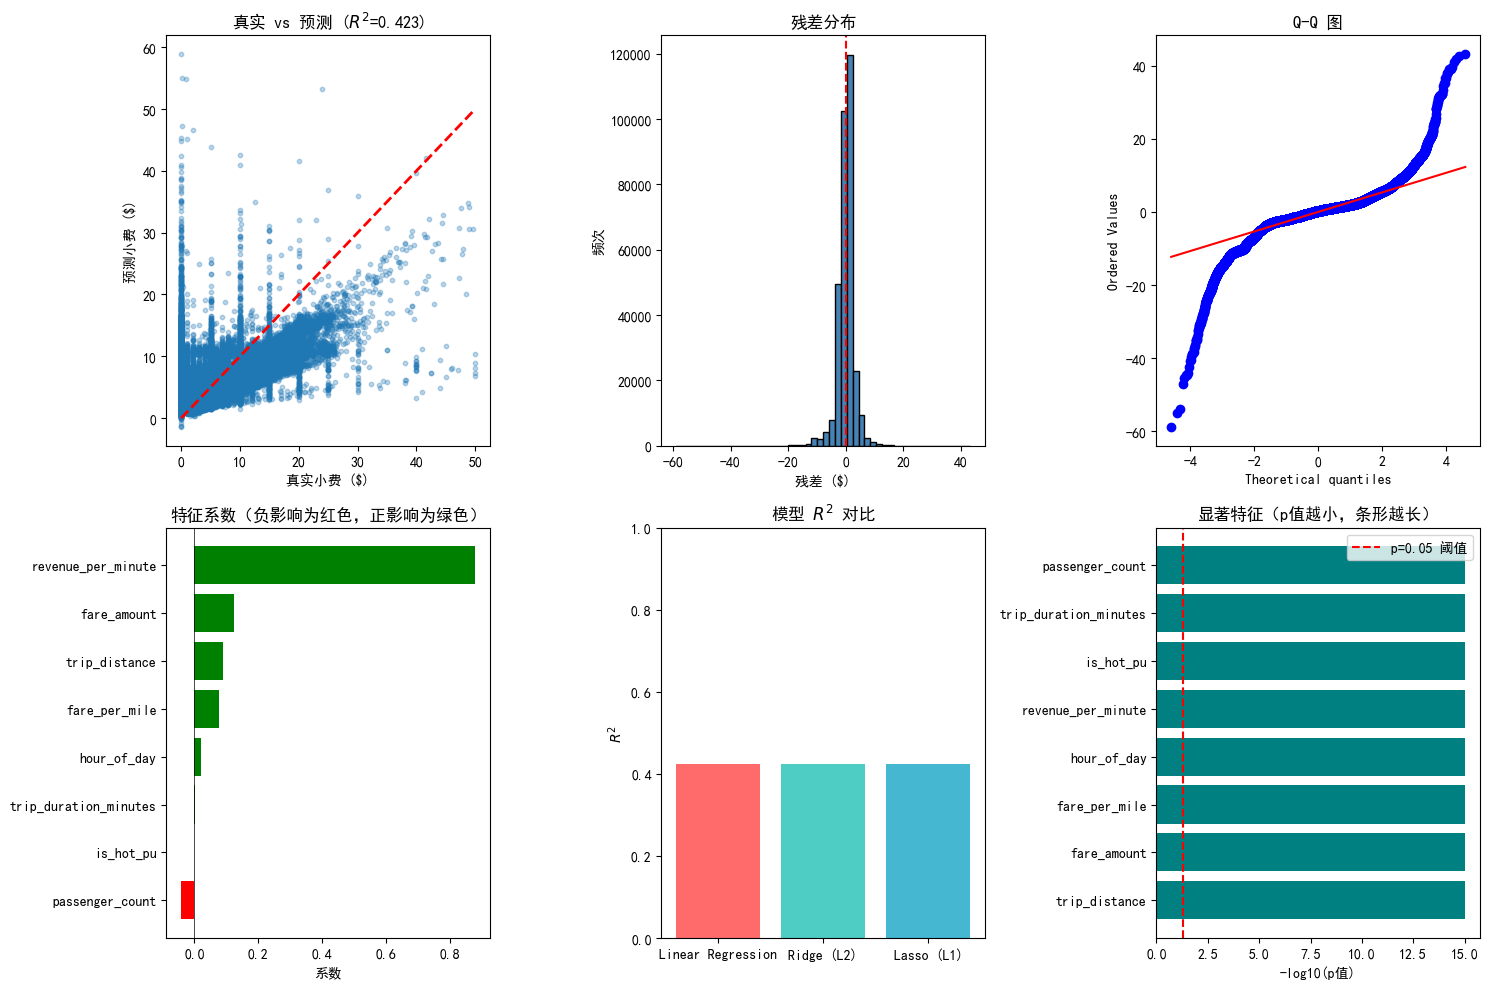


回归结果已保存到 D:/yellow_taxi/yellow_taxi_travel_regression/ 目录
- regression_coefficients.csv: 特征系数
- model_comparison.csv: 模型对比
- significant_features.csv: 显著特征统计
- regression_results.png: 可视化图表


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import os

save_dir = 'D:/yellow_taxi/yellow_taxi_travel_regression'
os.makedirs(save_dir, exist_ok=True)

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1. 加载之前生成的回归数据集
df = pd.read_parquet("D:/yellow_taxi/yellow_taxi_custom_factor/regression_data.parquet")
print(f"数据集大小: {df.shape[0]:,} 行, {df.shape[1]} 列")
print(f"列名: {df.columns.tolist()}")

print("\n=== 数据基本信息 ===")
print(df.info())

print("\n=== 前5行数据 ===")
print(df.head())

print("\n=== 缺失值统计 ===")
print(df.isnull().sum())

# 2. 数据预处理（为回归做准备）
# 将所有 bool 列转换为 int
bool_cols = df.select_dtypes(include=['bool']).columns
for col in bool_cols:
    df[col] = df[col].astype(int)

# 将所有 object 列转换为数值
for col in df.select_dtypes(include=['object']).columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 删除缺失值
df_clean = df.dropna()
print(f"删除缺失值后: {df_clean.shape[0]:,} 行")
# 检查数据类型
print(df_clean.dtypes)

# 过滤异常值, 避免极端值影响回归
df_clean = df_clean[
    (df_clean['tip_amount'] >= 0) &
    (df_clean['tip_amount'] <= 50) &
    (df_clean['fare_per_mile'] > 0) &
    (df_clean['fare_per_mile'] <= 20) &
    (df_clean['revenue_per_minute'] > 0) &
    (df_clean['revenue_per_minute'] <= 5)
]
print(f"过滤异常值后: {df_clean.shape[0]:,} 行")

# 3. 特征选择
# 特征列（数值型 + 编码后的类别型）
feature_cols = [
    'trip_distance',
    'passenger_count', 
    'fare_amount',
    'trip_duration_minutes',
    'hour_of_day',
    'fare_per_mile',
    'revenue_per_minute',
    'distance_category_code',
    'payment_type_code',
    'is_hot_pu'
]
# tip_rate作为特征可能引起数据泄露, 因为tip_amount是它的一部分, 所以这里不把tip_rate作为特征

# 检查哪些特征列实际存在
existing_features = [col for col in feature_cols if col in df_clean.columns]
print(f"使用的特征: {existing_features}")

# 因变量
target_col = 'tip_amount'

X = df_clean[existing_features].copy()
y = df_clean[target_col].copy()

print(f"\n特征矩阵形状: {X.shape}")
print(f"目标变量形状: {y.shape}")

# 4. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"训练集: {X_train.shape[0]:,} 行")
print(f"测试集: {X_test.shape[0]:,} 行")

# 5. statsmodels 线性回归（输出 p 值，判断显著性）
print("\n" + "="*60)
print("statsmodels 线性回归结果")
print("="*60)

# 添加常数项
X_train_sm = sm.add_constant(X_train)
# 训练模型
model_sm = sm.OLS(y_train, X_train_sm).fit()
# 输出完整摘要
print(model_sm.summary())

# 提取显著特征（p < 0.05）
significant_features = []
for var, pval in zip(model_sm.params.index, model_sm.pvalues):
    if pval < 0.05 and var != 'const':
        significant_features.append(var)
        print(f" {var}: p={pval:.6f} (显著)")
    elif var != 'const':
        print(f" {var}: p={pval:.6f} (不显著)")
print(f"\n显著特征 ({len(significant_features)}个): {significant_features}")

# 在测试集上评估
X_test_sm = sm.add_constant(X_test)
y_pred_sm = model_sm.predict(X_test_sm)
r2_sm = r2_score(y_test, y_pred_sm)
rmse_sm = np.sqrt(mean_squared_error(y_test, y_pred_sm))
print(f"\n测试集 R²: {r2_sm:.4f}")
print(f"测试集 RMSE: {rmse_sm:.4f}")

# 6. sklearn 线性回归（对比基准）
print("\n" + "="*60)
print("sklearn 线性回归结果")
print("="*60)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"测试集 R²: {r2_lr:.4f}")
print(f"测试集 RMSE: {rmse_lr:.4f}")

# 输出系数
coef_df = pd.DataFrame({
    'feature': existing_features,
    'coefficient': model_lr.coef_
}).sort_values('coefficient', ascending=False)
print("\n特征系数（按影响大小排序）:")
print(coef_df)

# 7. 正则化回归（Ridge / Lasso）- 可选加分
print("\n" + "="*60)
print("正则化回归对比")
print("="*60)

# 标准化特征（正则化需要）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge 回归
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# Lasso 回归
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# 汇总对比
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)'],
    'R²': [r2_lr, r2_ridge, r2_lasso],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso]
})
print(comparison_df)

# 8. 可视化回归结果
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 图1：真实值 vs 预测值（散点图）
axes[0, 0].scatter(y_test, y_pred_lr, alpha=0.3, s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('真实小费 ($)')
axes[0, 0].set_ylabel('预测小费 ($)')
axes[0, 0].set_title(f'真实 vs 预测 ($R^2$={r2_lr:.3f})')

# 图2：残差分布
residuals = y_test - y_pred_lr
axes[0, 1].hist(residuals, bins=50, edgecolor='black', color='steelblue')
axes[0, 1].set_xlabel('残差 ($)')
axes[0, 1].set_ylabel('频次')
axes[0, 1].set_title('残差分布')
axes[0, 1].axvline(x=0, color='red', linestyle='--')

# 图3：Q-Q图（检查正态性）
stats.probplot(residuals + 1e-6, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q 图')

# 图4：特征系数条形图（Top 10）
coef_df_sorted = coef_df.sort_values('coefficient', ascending=True)
top_features = coef_df_sorted.head(10)
colors_top = ['red' if x < 0 else 'green' for x in top_features['coefficient']]
axes[1, 0].barh(top_features['feature'], top_features['coefficient'], color=colors_top)
axes[1, 0].set_xlabel('系数')
axes[1, 0].set_title('特征系数（负影响为红色，正影响为绿色）')
axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# 图5：模型对比
axes[1, 1].bar(comparison_df['Model'], comparison_df['R²'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1, 1].set_ylabel(r'$R^2$')
axes[1, 1].set_title(r'模型 $R^2$ 对比')
axes[1, 1].set_ylim(0, 1)

# 图6：显著特征的 p 值（取负对数，越大越显著）
sig_pvalues = model_sm.pvalues[model_sm.pvalues < 0.05].drop('const', errors='ignore')
sig_pvalues = sig_pvalues.sort_values()
pvals_clipped = np.maximum(sig_pvalues, 1e-15)
neg_log_p = -np.log10(pvals_clipped)
axes[1, 2].barh(sig_pvalues.index, neg_log_p, color='teal')
axes[1, 2].set_xlabel('-log10(p值)')
axes[1, 2].set_title('显著特征（p值越小，条形越长）')
axes[1, 2].axvline(x=-np.log10(0.05), color='red', linestyle='--', label='p=0.05 阈值')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('D:/yellow_taxi/yellow_taxi_travel_regression/regression_results.png', dpi=150)
plt.show()

# 9. 保存关键结果
os.makedirs('D:/yellow_taxi/yellow_taxi_travel_regression', exist_ok=True)

# 保存回归系数
coef_df.to_csv('D:/yellow_taxi/yellow_taxi_travel_regression/regression_coefficients.csv', index=False)

# 保存模型对比结果
comparison_df.to_csv('D:/yellow_taxi/yellow_taxi_travel_regression/model_comparison.csv', index=False)

# 保存显著特征
sig_feature_df = pd.DataFrame({
    'feature': model_sm.params.index,
    'coefficient': model_sm.params.values,
    'p_value': model_sm.pvalues.values
}).sort_values('p_value')
sig_feature_df.to_csv('D:/yellow_taxi/yellow_taxi_travel_regression/significant_features.csv', index=False)

print("\n回归结果已保存到 D:/yellow_taxi/yellow_taxi_travel_regression/ 目录")
print("- regression_coefficients.csv: 特征系数")
print("- model_comparison.csv: 模型对比")
print("- significant_features.csv: 显著特征统计")
print("- regression_results.png: 可视化图表")